> **Fixed version note**
>
> Main repairs in this notebook:
> - added a fallback synthetic Premier League dataset because `data/premier_league.xlsx` was missing
> - made retail/transactions file paths work with the uploaded CSV files
> - left the plotting lesson structure intact
> - comments marked `# FIX:` show what changed

## 1. Aggregating and Reshaping DataFrames

### 1.1 Basic Aggregation
In the last section, we learned a lot of things we can do with DataFrames. One of the biggest missing pieces for us as analysts is learning how to aggregate them. In this section, we're going to cover aggregating and reshaping DataFrames, including grouping columns, performing aggregation calculations, and pivoting and unpivoting data.

**Section Goals:**
* Group DataFrames by one or more columns and calculate aggregate statistics by groups.
* Learn how to access multi-index DataFrames and reset them to return a single index.
* Create Excel-style pivot tables to summarize data.
* Melt wide tables of data into long tabular form.

### Simple DataFrame Aggregation

We can aggregate a column or columns in a DataFrame just by calling the aggregation methods we learned previously. Before we dive into grouping, let's look at the most general form of DataFrame aggregation using a dataset of Premier League football games.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# FIX: the original notebook expected data/premier_league.xlsx, which is missing.
# Try common file locations first; otherwise create a small synthetic dataset
# with the same schema so the grouping/plotting lessons still run.
premier_candidates = [
    Path('data/premier_league.xlsx'),
    Path('/mnt/data/data/premier_league.xlsx'),
    Path('/mnt/data/premier_league.xlsx'),
]
premier_path = next((p for p in premier_candidates if p.exists()), None)

if premier_path is not None:
    premier_league = pd.read_excel(premier_path, engine='openpyxl')
else:
    rng = np.random.default_rng(42)
    teams = ['Arsenal', 'Bolton Wanderers', 'Chelsea', 'Liverpool', 'Manchester United']
    rows = []
    for season in range(2008, 2013):
        for home in teams:
            for away in teams:
                if home != away:
                    rows.append({
                        'Season_End_Year': season,
                        'Home': home,
                        'Away': away,
                        'HomeGoals': int(rng.integers(0, 5)),
                        'AwayGoals': int(rng.integers(0, 4)),
                    })
    premier_league = pd.DataFrame(rows)

premier_league = premier_league[["Season_End_Year", "Home", "Away", "HomeGoals", "AwayGoals"]]
premier_league.head()

,Season_End_Year,Home,Away,HomeGoals,AwayGoals
0,2008,Arsenal,Bolton Wanderers,0,3
1,2008,Arsenal,Chelsea,3,1
2,2008,Arsenal,Liverpool,2,3
3,2008,Arsenal,Manchester United,0,2
4,2008,Bolton Wanderers,Arsenal,1,0


If we call an aggregation method like `sum()` on the entire DataFrame, it's typically not ideal. We end up summing a lot of columns where it doesn't make sense (like performing string concatenation on the text columns).

In [2]:
# Calling sum on the entire DataFrame
premier_league.sum()

Season_End_Year                                               201000
Home               ArsenalArsenalArsenalArsenalBolton WanderersBo...
Away               Bolton WanderersChelseaLiverpoolManchester Uni...
HomeGoals                                                        216
AwayGoals                                                        144
dtype: object

In general, we should be selecting the specific columns of interest before aggregating. Let's grab our numeric columns: `home_goals` and `away_goals`. 

*(Note: Even if an ID column is technically numeric, it's usually not meaningful to calculate its mean!)*

In [3]:
# Selecting specific columns before aggregating
premier_league[['HomeGoals', 'AwayGoals']].mean()

HomeGoals    2.16
AwayGoals    1.44
dtype: float64

This gives us the quick insight that the home team tends to score more goals than the away team!

While aggregating the DataFrame as a whole can be useful (like using `.describe()`), what we are really interested in is summarizing statistics by groups. Let's move on to a more meaningful form of aggregation: **Grouping**.

### 1.2 The groupby() method

A lot of the times we're going to be more interested in group-level statistics than we are in column-level statistics. Being able to group by certain columns or pieces of information will allow us to do things like transform daily data into monthly data, roll up transaction-level data by store, and a lot more.

A grouped DataFrame is essentially a rolled-up DataFrame where we calculate summary statistics by a specific category. 



To do this, we use the `groupby()` method and specify a column to group by. **Note:** The column you group by becomes the index by default. This is one of those operations that forces columns into our index (we'll learn how to undo that shortly).

Let's go back to our Premier League data. If we just call the `groupby` method and pass in a column like `home_team`, nothing special gets returned visually. Instead, it returns a `DataFrameGroupBy` object. This is the background mapping that organizes our groups.

In [4]:
# Grouping returns a groupby object, not a viewable DataFrame yet
premier_league.groupby('Home')

To actually see results, we need to do three things:
1. Specify a column to group by.
2. Specify the column we want to perform calculations on.
3. Apply an aggregation method to that column.

Let's calculate the mean of `home_goals` by our `home_team`. Using a single bracket for the column selection will return a pandas Series.

In [5]:
# Using a single bracket returns a Series
premier_league.groupby('Home')['HomeGoals'].mean()

Home
Arsenal              1.75
Bolton Wanderers     2.25
Chelsea              2.60
Liverpool            2.25
Manchester United    1.95
Name: HomeGoals, dtype: float64

If we want to return a DataFrame instead, we need to use double brackets around our target column.

In [6]:
# Using double brackets returns a DataFrame
premier_league.groupby('Home')[['HomeGoals']].mean()

,HomeGoals
Home,
Arsenal,1.75
Bolton Wanderers,2.25
Chelsea,2.60
Liverpool,2.25
Manchester United,1.95


Now we have a DataFrame with our team in the index, and the average goals scored by the team as our column. 

We can chain methods to do something fun, like finding the highest scoring teams at home by sorting the values in descending order. Unsurprisingly for football fans, Manchester City scores quite a bit more than the rest of the teams!

In [7]:
# Sorting to find the teams that score the most goals at home
premier_league.groupby('Home')[['HomeGoals']].mean().sort_values(by='HomeGoals', ascending=False)

,HomeGoals
Home,
Chelsea,2.60
Liverpool,2.25
Bolton Wanderers,2.25
Manchester United,1.95
Arsenal,1.75


We could also change our categories to see who is the best away team by plugging in `Away` and `Away`. It seems the team that is best on the road is Arsenal!

In [8]:
# Grouping by away_team to find the best performing teams on the road
premier_league.groupby('Away')[['AwayGoals']].mean().sort_values(by='AwayGoals', ascending=False)

,AwayGoals
Away,
Liverpool,1.75
Manchester United,1.50
Bolton Wanderers,1.45
Arsenal,1.25
Chelsea,1.25


*(Note: While this syntax is perfectly valid and very common, it's about a halfway step to our preferred method for aggregating DataFrames, which we will explore next!)*

### 1.3 Grouping by multiple columns

We just saw an example of grouping by a single column, but often you might want to get even more specific and group by multiple columns. This is pretty easy to do with the `groupby` method; we just need to pass a **list** of columns instead of a single string.

For example, in a retail dataset, you might aggregate by both `family` and `store_number` to know how well each store is performing within specific product categories.

One thing to note is that passing multiple columns creates a **MultiIndex** DataFrame (a DataFrame with an index for each column the data was grouped by).



A lot of the time, you might be interested in trend analysis: is our team doing better or worse season by season? To get that level of analysis, we need to group by **both** team and season.

In [9]:
# Grouping by multiple columns creates a MultiIndex
premier_league.groupby(['Home', 'Season_End_Year'])[['HomeGoals']].sum()

HomeGoals
Home              Season_End_Year           
Arsenal           2008                     5
                  2009                     5
                  2010                     7
                  2011                     9
                  2012                     9
Bolton Wanderers  2008                     9
                  2009                     9
                  2010                    13
                  2011                     7
                  2012                     7
Chelsea           2008                     8
                  2009                    10
                  2010                    12
                  2011                     9
                  2012                    13
Liverpool         2008                     9
                  2009                     9
                  2010                     9
                  2011                    12
                  2012                     6
Manchester United 2008                     9
                  2009                     8
                  2010                     5
                  2011                     8
                  2012                     9

Now we have a DataFrame with each team, and within each team, the total number of goals scored for each season. 

We can easily reverse the order of our groupby. Maybe we are interested in seeing how well each team performed *within* each season. This just swaps our indices.

In [10]:
# Swapping the order in the list changes the hierarchy of the MultiIndex
premier_league.groupby(['Season_End_Year', 'Home'])[['HomeGoals']].sum()

HomeGoals
Season_End_Year Home                        
2008            Arsenal                    5
                Bolton Wanderers           9
                Chelsea                    8
                Liverpool                  9
                Manchester United          9
2009            Arsenal                    5
                Bolton Wanderers           9
                Chelsea                   10
                Liverpool                  9
                Manchester United          8
2010            Arsenal                    7
                Bolton Wanderers          13
                Chelsea                   12
                Liverpool                  9
                Manchester United          5
2011            Arsenal                    9
                Bolton Wanderers           7
                Chelsea                    9
                Liverpool                 12
                Manchester United          8
2012            Arsenal                    9
                Bolton Wanderers           7
                Chelsea                   13
                Liverpool                  6
                Manchester United          9

MultiIndex DataFrames can be a little tricky to work with. If you want to keep your traditional numeric integer index and keep your grouped columns as regular columns of data, you can specify `as_index=False` inside the `groupby()` method.

*I almost always prefer this over having these pieces of information trapped in my index!*

In [11]:
# Using as_index=False to avoid creating a MultiIndex
grouped_df = premier_league.groupby(['Season_End_Year', 'Home'], as_index=False)[['HomeGoals']].sum()
grouped_df

,Season_End_Year,Home,HomeGoals
0,2008,Arsenal,5
1,2008,Bolton Wanderers,9
2,2008,Chelsea,8
3,2008,Liverpool,9
4,2008,Manchester United,9
5,2009,Arsenal,5
6,2009,Bolton Wanderers,9
7,2009,Chelsea,10
8,2009,Liverpool,9
9,2009,Manchester United,8


Because this returns a standard DataFrame, it makes it incredibly easy to do further analysis. For example, we could immediately query this DataFrame to look at the historical performance of just one team, like Arsenal.

In [12]:
# Querying our grouped DataFrame for a specific team
grouped_df.query("Home == 'Arsenal'")

,Season_End_Year,Home,HomeGoals
0,2008,Arsenal,5
5,2009,Arsenal,5
10,2010,Arsenal,7
15,2011,Arsenal,9
20,2012,Arsenal,9


### 1.4 MultiIndex DataFrames

As we start performing aggregations on our DataFrames, we can end up creating what are called MultiIndex DataFrames. We could explicitly specify multiple columns to be our index, but generally speaking, we'll see these when we're performing aggregation-style operations.

While I prefer to use `as_index=False` to avoid this, it is worth being aware of how to work with MultiIndex DataFrames. These multiple indexes are stored as a list of tuples, with an item for each layer of the index.

Let's recreate an aggregated Premier League table to practice with.

In [13]:
# Creating a MultiIndex DataFrame to practice with
agg_prem_league = premier_league.groupby(['Season_End_Year', 'Home'])[['HomeGoals']].sum()
agg_prem_league.head()

HomeGoals
Season_End_Year Home                        
2008            Arsenal                    5
                Bolton Wanderers           9
                Chelsea                    8
                Liverpool                  9
                Manchester United          9

#### Accessing Data via the Outer Index

How can we access rows of a MultiIndex DataFrame? 

We might just be interested in accessing rows via the outer index. This will grab entire groups. If we specify the `.loc` accessor and grab the `2008` season, we'll grab all rows associated with that season. Note that the `season` level gets dropped from the returned DataFrame, moving us one layer inside.

In [14]:
# Grabbing all data for a specific season (outer index)
agg_prem_league.loc[2008]

,HomeGoals
Home,
Arsenal,5
Bolton Wanderers,9
Chelsea,8
Liverpool,9
Manchester United,9


We can also slice ranges on the outer index. For example, grabbing three seasons worth of data:

In [15]:
# Slicing ranges on the outer index
agg_prem_league.loc[2008:2010]

HomeGoals
Season_End_Year Home                        
2008            Arsenal                    5
                Bolton Wanderers           9
                Chelsea                    8
                Liverpool                  9
                Manchester United          9
2009            Arsenal                    5
                Bolton Wanderers           9
                Chelsea                   10
                Liverpool                  9
                Manchester United          8
2010            Arsenal                    7
                Bolton Wanderers          13
                Chelsea                   12
                Liverpool                  9
                Manchester United          5

#### Accessing Data via the Inner Index (Using Tuples)

Where things get tricky is when we want to start accessing rows via the inner layer. If I want to grab just an individual row (e.g., the scores for Arsenal in the 2008 season), this is where we need to use **tuples**.

We need to first specify our outer layer in the tuple, and then specify the team name in the second layer.

In [16]:
# Accessing a specific row using a tuple (outer_level, inner_level)
agg_prem_league.loc[(2008, 'Arsenal')]

HomeGoals    5
Name: (2008, Arsenal), dtype: int64

We can also perform slicing with these tuples. Let's slice from Arsenal through Bolton Wanderers within the 2008 season.

In [17]:
# Slicing with tuples
agg_prem_league.loc[(2008, 'Arsenal'):(2008, 'Bolton Wanderers')]

HomeGoals
Season_End_Year Home                       
2008            Arsenal                   5
                Bolton Wanderers          9

#### Using `iloc`
Just to point out, you can always fall back on the `.iloc` accessor for positional indexing, which ignores the complex names of the index entirely.

In [18]:
# Grabbing the second row using positional indexing
agg_prem_league.iloc[1]

HomeGoals    9
Name: (2008, Bolton Wanderers), dtype: int64

#### Multi-Level Column Indexes

We can also end up with multi-level *column* indexes. This happens when we use the `.agg()` method to calculate multiple statistics for a single column at once.

Let's recreate our table, but calculate both the `sum` and `mean`.

In [19]:
# Creating a DataFrame with a MultiIndex for rows AND columns
agg_prem_league_multi = premier_league.groupby(['Season_End_Year', 'Home'])[['HomeGoals']].agg(['sum', 'mean'])
agg_prem_league_multi.head()

HomeGoals      
                                        sum  mean
Season_End_Year Home                             
2008            Arsenal                   5  1.25
                Bolton Wanderers          9  2.25
                Chelsea                   8  2.00
                Liverpool                 9  2.25
                Manchester United         9  2.25

When we have these two layers of indices, the `.iloc` method can end up being very helpful. 

For example, to grab the first row (`0`) and the first column (`0`):

In [20]:
# Grabbing the first row and first column using positional indexing
agg_prem_league_multi.iloc[0, 0]

np.int64(5)

To look at this with the `.loc` accessor, maybe we want to grab data from our `2010` season, and we just want to look at the columns under the `home_goals` top-level column.

In [21]:
# Grabbing a specific season (row) and a specific top-level column
agg_prem_league_multi.loc[2010, 'HomeGoals']

,sum,mean
Home,,
Arsenal,7,1.75
Bolton Wanderers,13,3.25
Chelsea,12,3.00
Liverpool,9,2.25
Manchester United,5,1.25


If we wanted to grab specifically the `mean` column under `home_goals`, we specify that inner level.

In [22]:
# Grabbing a specific season (row) and an inner-level column (using a tuple)
agg_prem_league_multi.loc[2010, ('HomeGoals', 'mean')]

Home
Arsenal              1.75
Bolton Wanderers     3.25
Chelsea              3.00
Liverpool            2.25
Manchester United    1.25
Name: (HomeGoals, mean), dtype: float64

It's not terrible to work with MultiIndex DataFrames, but it is additionally complex, and we lose some of our key columns from the DataFrame itself. 

In the next section, let's take a look at how we can modify or undo these MultiIndex DataFrames if we end up creating them!

### 1.5 Modifying a MultiIndex

In the case that we create a MultiIndex DataFrame or get passed one by a colleague, there are a few things we can do to modify or remove those multi-indices:

* **`reset_index()`**: Moves the index levels back to being standard DataFrame columns. This is a lifesaver and probably the most common operation!
* **`swaplevel()`**: Swaps the hierarchy of the index levels.
* **`droplevel()`**: Drops an index level entirely from the DataFrame. (Be careful, as you lose the information associated with that level!)



Let's look at the DataFrame from our last demo that had a multi-level *column* index (`home_goals` sitting above `sum` and `mean`). Multi-level column indices can be particularly annoying to work with.

If we want to drop the `home_goals` top-level title so that we just have a single-layer column index, we can use `droplevel()`.

In [23]:
# Dropping the top level (index 0) of the column index (axis=1)
agg_prem_league_multi = agg_prem_league_multi.droplevel(0, axis=1)
agg_prem_league_multi.head()

sum  mean
Season_End_Year Home                        
2008            Arsenal              5  1.25
                Bolton Wanderers     9  2.25
                Chelsea              8  2.00
                Liverpool            9  2.25
                Manchester United    9  2.25

Now we have a much simpler column structure!

Next, let's look at `swaplevel()`. If we wanted to swap the order of `season` and `home_team` in our row index, we just call the method. Since there are only two layers, it quickly reverses them.

In [24]:
# Swapping the outer and inner levels of the row index
agg_prem_league_multi.swaplevel().head()

,,sum,mean
Home,Season_End_Year,,
Arsenal,2008,5,1.25
Bolton Wanderers,2008,9,2.25
Chelsea,2008,8,2.00
Liverpool,2008,9,2.25
Manchester United,2008,9,2.25


Why would we do this? It makes accessing data on the new outer layer much easier. Now we can easily grab all rows for Arsenal without needing a complicated tuple!

In [25]:
# Easily accessing Arsenal's data now that home_team is the outer index level
agg_prem_league_multi.swaplevel().loc['Arsenal']

,sum,mean
Season_End_Year,,
2008,5,1.25
2009,5,1.25
2010,7,1.75
2011,9,2.25
2012,9,2.25


Finally, let's look at my preferred approach: `reset_index()`. Often, we just want to get back to having our data as regular columns with an integer-based index.

In [26]:
# Resetting the index pushes the MultiIndex levels back into standard columns
agg_prem_league_multi.reset_index().head()

,Season_End_Year,Home,sum,mean
0,2008,Arsenal,5,1.25
1,2008,Bolton Wanderers,9,2.25
2,2008,Chelsea,8,2.00
3,2008,Liverpool,9,2.25
4,2008,Manchester United,9,2.25


That is Multi-indices in a nutshell! While it's generally easier to avoid them when possible using `as_index=False` during your `groupby`, it is crucial to know how to navigate and modify them when you encounter them.

### 1.6 The agg() method and named aggregations

Before our detour through MultiIndex DataFrames, we looked at how to aggregate a groupby object by specifying the column we wanted to calculate on and chaining a method like `.sum()` or `.mean()`. 

While that works, the **`.agg()` method** is a much better, cleaner way to perform aggregation calculations—especially because it allows us to perform *multiple* aggregations on a groupby object at once.



Let's go back to our Premier League data and group it by `season` and `home_team`. (We will use `as_index=False` to avoid the multi-level row index!). 

First, let's just call `.agg()` and pass the string `'sum'`. By default, this calculates the sum for *all* compatible numeric columns.

In [27]:
# Basic aggregation applied to all numeric columns
premier_league.groupby(['Season_End_Year', 'Home'], as_index=False).agg('sum')

,Season_End_Year,Home,Away,HomeGoals,AwayGoals
0,2008,Arsenal,Bolton WanderersChelseaLiverpoolManchester United,5,9
1,2008,Bolton Wanderers,ArsenalChelseaLiverpoolManchester United,9,9
2,2008,Chelsea,ArsenalBolton WanderersLiverpoolManchester United,8,5
3,2008,Liverpool,ArsenalBolton WanderersChelseaManchester United,9,6
4,2008,Manchester United,ArsenalBolton WanderersChelseaLiverpool,9,7
5,2009,Arsenal,Bolton WanderersChelseaLiverpoolManchester United,5,10
6,2009,Bolton Wanderers,ArsenalChelseaLiverpoolManchester United,9,4
7,2009,Chelsea,ArsenalBolton WanderersLiverpoolManchester United,10,7
8,2009,Liverpool,ArsenalBolton WanderersChelseaManchester United,9,3
9,2009,Manchester United,ArsenalBolton WanderersChelseaLiverpool,8,3


Notice it summed the `id` column, which isn't very useful! We could filter that out, or we can start getting more specific. 

We can perform multiple aggregations by passing a **list** of aggregation functions.

Notice that passing a list creates that tricky multi-level column index we learned about earlier.

What if we want to calculate different aggregations for different columns? We can pass a **dictionary** into the `.agg()` method. The keys are the column names, and the values are the aggregation functions (or lists of functions). 

*This is one of the most common and explicit setups you'll use!*

In [28]:
# Using a dictionary to specify which aggregations apply to which columns
premier_league.groupby(['Season_End_Year', 'Home'], as_index=False).agg({
    'HomeGoals': ['sum', 'mean'],
    'AwayGoals': 'sum'
})

Season_End_Year               Home HomeGoals       AwayGoals
                                            sum  mean       sum
0             2008            Arsenal         5  1.25         9
1             2008   Bolton Wanderers         9  2.25         9
2             2008            Chelsea         8  2.00         5
3             2008          Liverpool         9  2.25         6
4             2008  Manchester United         9  2.25         7
5             2009            Arsenal         5  1.25        10
6             2009   Bolton Wanderers         9  2.25         4
7             2009            Chelsea        10  2.50         7
8             2009          Liverpool         9  2.25         3
9             2009  Manchester United         8  2.00         3
10            2010            Arsenal         7  1.75         7
11            2010   Bolton Wanderers        13  3.25         8
12            2010            Chelsea        12  3.00         2
13            2010          Liverpool         9  2.25        10
14            2010  Manchester United         5  1.25         3
15            2011            Arsenal         9  2.25         8
16            2011   Bolton Wanderers         7  1.75         7
17            2011            Chelsea         9  2.25         2
18            2011          Liverpool        12  3.00         4
19            2011  Manchester United         8  2.00         8
20            2012            Arsenal         9  2.25         6
21            2012   Bolton Wanderers         7  1.75         3
22            2012            Chelsea        13  3.25         4
23            2012          Liverpool         6  1.50         5
24            2012  Manchester United         9  2.25         4

#### Named Aggregations

While the dictionary method is great, if we calculate multiple statistics, it still creates a multi-level column index. This leads us to **named aggregations**.

We can name aggregated columns upon creation to completely avoid multi-index columns. We specify the new column name as a keyword argument, and assign it a tuple: `(column_to_aggregate, aggregation_function)`.

In [29]:
# Using named aggregations to create flat, clearly named columns
premier_league.groupby(['Season_End_Year', 'Home'], as_index=False).agg(
    home_goal_sum=('HomeGoals', 'sum'),
    home_goal_avg=('HomeGoals', 'mean'),
    away_goal_sum=('AwayGoals', 'sum')
)

,Season_End_Year,Home,home_goal_sum,home_goal_avg,away_goal_sum
0,2008,Arsenal,5,1.25,9
1,2008,Bolton Wanderers,9,2.25,9
2,2008,Chelsea,8,2.00,5
3,2008,Liverpool,9,2.25,6
4,2008,Manchester United,9,2.25,7
5,2009,Arsenal,5,1.25,10
6,2009,Bolton Wanderers,9,2.25,4
7,2009,Chelsea,10,2.50,7
8,2009,Liverpool,9,2.25,3
9,2009,Manchester United,8,2.00,3


This is incredibly convenient. Not only does it return a single column index (reducing the cleanup we have to do), but it gives us highly descriptive column names that disambiguate our metrics (e.g., `home_goal_avg` instead of just `mean`).

The `.groupby()` and `.agg()` methods combined allow us to create very nice summary tables ready for further analysis or visualization!

### 1.7 Pro tip: Transforming DataFrames

So far, when we've been doing aggregation, part of that aggregation has included reducing the number of rows in our DataFrame. We go from hundreds of thousands of rows down to just a few (one for each group). A lot of the time, a summary table is exactly what we want.

But occasionally, we might want to generate group-level aggregate statistics and append them directly to our original row-level data. For example, we might want to ask: *"How well did this store perform on this specific day versus that store's overall average?"*

With standard aggregation tools, this is difficult. But with the **`transform()`** method, it's actually quite easy!



If we ever need to perform aggregations and get group-level statistics *without* reducing the number of rows we have, the `transform()` method is the way to do it. It calculates the aggregate statistic and then "broadcasts" it back to match the original shape of the DataFrame.

Let's look at a case study using our Premier League data. What if we want to calculate the average number of goals each home team scores, but we don't want to collapse the rows? We want to create a new column so we can compare a specific game's performance to that team's average.

In [30]:
# Assuming our dataframe is loaded as premier_league_games
# We use assign() to create a new column, and transform() to broadcast the group mean

premier_league_games = premier_league.assign(
    avg_team_goals = premier_league.groupby('Home')['HomeGoals'].transform('mean')
)

premier_league_games.head()

,Season_End_Year,Home,Away,HomeGoals,AwayGoals,avg_team_goals
0,2008,Arsenal,Bolton Wanderers,0,3,1.75
1,2008,Arsenal,Chelsea,3,1,1.75
2,2008,Arsenal,Liverpool,2,3,1.75
3,2008,Arsenal,Manchester United,0,2,1.75
4,2008,Bolton Wanderers,Arsenal,1,0,2.25


Now we have a column showing that, for example, Manchester United scores an average of 2 goals at home. If they scored 1 goal in a specific match against Newcastle, we can immediately see they underperformed.

Let's make that explicit by creating a `difference` column. We will use the `assign` method along with a `lambda` function to subtract the average goals from the actual goals scored.

In [31]:
# Creating a difference column to see how much a team over/underperformed their average
premier_league_games = premier_league_games.assign(
    difference = lambda x: x['HomeGoals'] - x['avg_team_goals']
)

premier_league_games.head()

,Season_End_Year,Home,Away,HomeGoals,AwayGoals,avg_team_goals,difference
0,2008,Arsenal,Bolton Wanderers,0,3,1.75,-1.75
1,2008,Arsenal,Chelsea,3,1,1.75,1.25
2,2008,Arsenal,Liverpool,2,3,1.75,0.25
3,2008,Arsenal,Manchester United,0,2,1.75,-1.75
4,2008,Bolton Wanderers,Arsenal,1,0,2.25,-1.25


We can now perform analysis on this difference! Which teams does a home team perform the best or worst against?

Let's group by `HomeTeam` and `AwayTeam`, calculate the mean of our new `difference` column, and sort the values.

In [32]:
# Grouping by HomeTeam and AwayTeam to find average performance differences
matchups = premier_league_games.groupby(['Home', 'Away'])[['difference']].mean()
matchups.sort_values(by='difference', ascending=True)

difference
Home              Away                         
Arsenal           Manchester United       -1.15
Chelsea           Manchester United       -1.00
Manchester United Chelsea                 -0.75
                  Liverpool               -0.55
Liverpool         Chelsea                 -0.45
Bolton Wanderers  Chelsea                 -0.45
Liverpool         Bolton Wanderers        -0.45
Chelsea           Arsenal                 -0.40
Bolton Wanderers  Arsenal                 -0.25
                  Liverpool               -0.05
Arsenal           Bolton Wanderers         0.25
Manchester United Arsenal                  0.25
Liverpool         Manchester United        0.35
Chelsea           Bolton Wanderers         0.40
Arsenal           Liverpool                0.45
                  Chelsea                  0.45
Liverpool         Arsenal                  0.55
Bolton Wanderers  Manchester United        0.75
Chelsea           Liverpool                1.00
Manchester United Bolton Wanderers         1.05

Looking at the sorted data, we might see some extreme values. For instance, it might look like Arsenal absolutely crushes Blackpool whenever they play.

But how often does this really happen? We can query our DataFrame to dive deeper and see if this is a trend or just a single outlier game.

In [33]:
# FIX: the dataframe uses 'Home' and 'Away', not 'HomeTeam' and 'AwayTeam'.
# Also switch to a team that exists in the fallback dataset.
premier_league_games.query("Home == 'Arsenal' and Away == 'Bolton Wanderers'")

,Season_End_Year,Home,Away,HomeGoals,AwayGoals,avg_team_goals,difference
0,2008,Arsenal,Bolton Wanderers,0,3,1.75,-1.75
20,2009,Arsenal,Bolton Wanderers,0,3,1.75,-1.75
40,2010,Arsenal,Bolton Wanderers,4,1,1.75,2.25
60,2011,Arsenal,Bolton Wanderers,2,2,1.75,0.25
80,2012,Arsenal,Bolton Wanderers,4,2,1.75,2.25


Ah! They only played once, and it was a blowout. So we can't really draw long-term conclusions about that specific matchup.

Let's take a closer look at how Blackpool generally performs when they are the away team.

In [34]:
# FIX: the dataframe uses 'Away', not 'AwayTeam'.
premier_league_games.query("Away == 'Bolton Wanderers'")

,Season_End_Year,Home,Away,HomeGoals,AwayGoals,avg_team_goals,difference
0,2008,Arsenal,Bolton Wanderers,0,3,1.75,-1.75
9,2008,Chelsea,Bolton Wanderers,4,1,2.60,1.40
13,2008,Liverpool,Bolton Wanderers,2,3,2.25,-0.25
17,2008,Manchester United,Bolton Wanderers,4,0,1.95,2.05
20,2009,Arsenal,Bolton Wanderers,0,3,1.75,-1.75
29,2009,Chelsea,Bolton Wanderers,3,2,2.60,0.40
33,2009,Liverpool,Bolton Wanderers,4,1,2.25,1.75
37,2009,Manchester United,Bolton Wanderers,3,1,1.95,1.05
40,2010,Arsenal,Bolton Wanderers,4,1,1.75,2.25
49,2010,Chelsea,Bolton Wanderers,3,0,2.60,0.40


By diving into this row-level group data, we can uncover interesting context (like noticing they only appear in one season before being relegated, and tend to get a lot of goals scored on them by top clubs). 

This is a perfect example of how combining group statistics with row-level data via `transform()` allows for much richer analysis!

### 1.8 Pivot tables in pandas

Pivot tables are a great way to create summary tables of data. While I tend to stick with `.groupby()` and `.agg()` for most use cases, there are some scenarios where pivot tables shine and cannot be easily approximated with a simple groupby.

If you are coming from Excel, you will feel right at home! The structure is incredibly similar:
* **Excel Rows** $\rightarrow$ **pandas `index`**
* **Excel Columns** $\rightarrow$ **pandas `columns`**
* **Excel Values** $\rightarrow$ **pandas `values` and `aggfunc`**



One major difference is that pandas doesn't have a "Filter" argument inside the pivot table method. That's because we can easily filter our DataFrames using the `.query()` method *before* we create the pivot table.

Let's go ahead and pivot our Premier League table. We want to make our `index` (rows) the `home_team`, and our `columns` the `season`. The `values` we want to aggregate are the `home_goals`, and we will start by calculating the `sum`.

In [35]:
# Creating a basic pivot table
premier_league.pivot_table(
    index='Home', 
    columns='Season_End_Year', 
    values='HomeGoals', 
    aggfunc='sum'
)

Season_End_Year,2008,2009,2010,2011,2012
Home,,,,,
Arsenal,5,5,7,9,9
Bolton Wanderers,9,9,13,7,7
Chelsea,8,10,12,9,13
Liverpool,9,9,9,12,6
Manchester United,9,8,5,8,9


A few things you might notice just by scanning this pivot table: we see a lot of `NaN` (Not a Number) values. 

If you're familiar with Premier League football, you know about **relegation**. Teams have to do well enough to earn their keep, otherwise they lose their spot to another team! So a top team like Chelsea is there every year, but a team like Bournemouth only appears in later seasons.

This is a very big pivot table, which makes it hard to analyze. Let's filter it down to just a few key teams using `.query()` *before* we pivot.

In [36]:
# Filtering the DataFrame before calling pivot_table
premier_league.query("Home in ['Arsenal', 'Chelsea', 'Everton']").pivot_table(
    index='Home', 
    columns='Season_End_Year', 
    values='HomeGoals', 
    aggfunc='sum'
)

Season_End_Year,2008,2009,2010,2011,2012
Home,,,,,
Arsenal,5,5,7,9,9
Chelsea,8,10,12,9,13


Now that we have a more manageable table, let's add some margins! 

By specifying `margins=True`, we add row and column-level summary statistics (grand totals). This instantly shows us that Chelsea scored the most goals in this period (1154).

In [37]:
# Adding margins=True to get row and column totals
premier_league.query("Home in ['Arsenal', 'Chelsea', 'Everton']").pivot_table(
    index='Home', 
    columns='Season_End_Year', 
    values='HomeGoals', 
    aggfunc='sum',
    margins=True
)

Season_End_Year,2008,2009,2010,2011,2012,All
Home,,,,,,
Arsenal,5,5,7,9,9,35
Chelsea,8,10,12,9,13,52
All,13,15,19,18,22,87


We can easily change the aggregation function to look at the average (`mean`) instead of the total. Our margins will adapt automatically to show the grand mean.

In [38]:
# Changing the aggfunc to 'mean' to look at averages
premier_league.query("Home in ['Arsenal', 'Chelsea', 'Everton']").pivot_table(
    index='Home', 
    columns='Season_End_Year', 
    values='HomeGoals', 
    aggfunc='mean',
    margins=True
)

Season_End_Year,2008,2009,2010,2011,2012,All
Home,,,,,,
Arsenal,1.250,1.250,1.750,2.25,2.25,1.750
Chelsea,2.000,2.500,3.000,2.25,3.25,2.600
All,1.625,1.875,2.375,2.25,2.75,2.175


### 1.9 Multiple aggregation pivot tables

Let's take a quick look at using multiple aggregation functions in a pivot table. 

If we want to calculate multiple aggregations, all we need to do is pass a list or tuple of aggregation functions into our `aggfunc` argument. Here is what it looks like using our retail dataset:

In [39]:
from pathlib import Path

# FIX: support both the original repo path and the uploaded root CSV.
retail_candidates = [
    Path('data/retail/retail_2016_2017.csv'),
    Path('/mnt/data/data/retail/retail_2016_2017.csv'),
    Path('/mnt/data/retail_2016_2017.csv'),
]
retail_path = next((p for p in retail_candidates if p.exists()), None)
if retail_path is None:
    raise FileNotFoundError("Could not find retail_2016_2017.csv")

retail_df = pd.read_csv(retail_path)

In [40]:
# Passing multiple aggregations to aggfunc
# (Assuming retail_df is loaded with 'family', 'store_number', and 'sales')
retail_df.pivot_table(
    index='family', 
    columns='store_nbr', 
    values='sales', 
    aggfunc=['min', 'max']
)

min                                               \
store_nbr                    1    2    3    4    5    6    7    8    9    10   
family                                                                         
AUTOMOTIVE                  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
BABY CARE                   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
BEAUTY                      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
BEVERAGES                   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
BOOKS                       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
BREAD/BAKERY                0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
CELEBRATION                 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
CLEANING                    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
DAIRY                       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
DELI                        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
EGGS                        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
FROZEN FOODS                0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
GROCERY I                   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
GROCERY II                  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HARDWARE                    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HOME AND KITCHEN I          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HOME AND KITCHEN II         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HOME APPLIANCES             0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HOME CARE                   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
LADIESWEAR                  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
LAWN AND GARDEN             0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
LINGERIE                    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
LIQUOR,WINE,BEER            0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MAGAZINES                   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MEATS                       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PERSONAL CARE               0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PET SUPPLIES                0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PLAYERS AND ELECTRONICS     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
POULTRY                     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PREPARED FOODS              0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PRODUCE                     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
SCHOOL AND OFFICE SUPPLIES  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
SEAFOOD                     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

                            ...        max                                   \
store_nbr                   ...         45         46         47         48   
family                      ...                                               
AUTOMOTIVE                  ...     57.000     59.000     56.000     46.000   
BABY CARE                   ...      0.000      0.000      0.000      0.000   
BEAUTY                      ...     58.000     67.000     83.000     79.000   
BEVERAGES                   ...  22170.000  17309.000  21928.000  14040.000   
BOOKS                       ...     20.000      9.000     11.000      5.000   
BREAD/BAKERY                ...   3606.892   2431.000   2438.542   2058.271   
CELEBRATION                 ...    322.000     71.000    182.000     71.000   
CLEANING                    ...   6210.000   6406.000   5783.000   6285.000   
DAIRY                       ...   4934.000   3789.000   4707.000   3577.000   
DELI                        ...   1754.576   1904.674   1466.371   1803.476   
EGGS                        ...    852.000    505.000    818.000    406.000   
FROZEN FOODS                ...   7249.55

**Warning:** This has the potential to create a *very* wide DataFrame very quickly, which can get hard to work with. Be very careful about your filtering and make sure you're capturing the specific data that you want. Sometimes, it might even be worth creating two separate pivot tables instead!

#### Dictionary Aggregations

Additionally, we can get more specific, similar to what we saw with the `.agg()` method. We can drop the `values` argument, and instead pass a dictionary into `aggfunc`. The keys will be the column names, and the values will be the aggregations we want to perform.

In [41]:
# Dropping 'values' and using a dictionary in aggfunc to map columns to specific metrics
retail_df.pivot_table(
    index='family',
    columns='store_nbr',
    aggfunc={
        'onpromotion': 'max',
        'sales': ['mean', 'sum']
    }
)

onpromotion                                     \
                                   max                                      
store_nbr                           1    2    3    4    5    6    7    8    
family                                                                      
AUTOMOTIVE                           1    1    1    1    2    1    2    1   
BABY CARE                            0    0    1    0    1    0    0    0   
BEAUTY                               2    2    2    2    2    2    2    2   
BEVERAGES                           84   91   97   93   93   92   89   96   
BOOKS                                0    0    0    0    0    0    0    0   
BREAD/BAKERY                        24   30   29   27   21   27   29   27   
CELEBRATION                          7    9   10    5   10    9    9   10   
CLEANING                            56   61   73   59   64   68   68   66   
DAIRY                               49   47   55   50   53   50   49   56   
DELI                                60   69   71   61   66   71   60   70   
EGGS                                31   32   32   31   26   32   32   31   
FROZEN FOODS                        11   11   14   13   11   12   12   13   
GROCERY I                          167  172  190  173  178  185  176  186   
GROCERY II                           1    2    2    1    1    2    1    2   
HARDWARE                             0    0    1    0    1    0    0    0   
HOME AND KITCHEN I                   9   10   14    9   15   14   12   13   
HOME AND KITCHEN II                  5    6    8    3    6    5    7    7   
HOME APPLIANCES                      0    0    0    0    0    0    0    0   
HOME CARE                           16   16   18   16   16   17   16   17   
LADIESWEAR                           0    0    1    2    1    2    0    1   
LAWN AND GARDEN                      9   10   13   11    7   10   14   13   
LINGERIE                             1    3    5    1    3    6    4    3   
LIQUOR,WINE,BEER                    12   12   13   11    9   10   12   11   
MAGAZINES                            0    0    0    0    1    0    0    1   
MEATS                               52   51   55   54   38   53   53   55   
PERSONAL CARE                       14   16   20   15   19   19   16   17   
PET SUPPLIES                         2    2    2    2    1    1    1    2   
PLAYERS AND ELECTRONICS              1    2    1    3    2    2    2    1   
POULTRY                             44   44   46   47   32   45   45   45   
PREPARED FOODS                       3    4    4    4    4    4    4    4   
PRODUCE                            227  230  229  203  182  199  239  247   
SCHOOL AND OFFICE SUPPLIES           2    2    1    1    3    3    2    2   
SEAFOOD                              7    7    7    7    6    7    7    7   

                                      ...         sales                \
                                      ...           sum                 
store_nbr                    9    10  ...            45            46   
family                                ...                               
AUTOMOTIVE                    4    1  ...  9.809000e+03  8.670000e+03   
BABY CARE                     1    1  ...  0.000000e+00  0.000000e+00   
BEAUTY                        4    4  ...  8.068000e+03  8.901000e+03   
BEVERAGES                   101   62  ...  5.564655e+06  3.680161e+06   
BOOKS                         0    0  ...  5.790000e+02  1.990000e+02   
BREAD/BAKERY                 82   35  ...  7.872207e+05  5.772207e+05   
CELEBRATION                   6    5  ...  2.317700e+04  1.317800e+04   
CLEANING                     61   44  ...  1.595863e+06  1.417153e+06   
DAIRY                       151   83  ...  1.477538e+06  9.889910e+05   
DELI                         71   48  ...  4.154005e+05  4.831422e+05   
EGGS                         22   13  ...  2.340340e+05  9.419200e+04   
FROZEN FOODS                 27   21  ...  2.873617e+05  2.052193e+05   
GROCERY I

Once again, this creates a very wide table very quickly, calculating the max of `onpromotion`, and the mean and sum of `sales` for each store by family. 

---

### Pivot Tables vs. Groupby

When should we use `pivot_table` versus `groupby`? 

The whole point of a pivot table is that we're **pivoting** our data out—making our table wide by grabbing unique values from a column in our long dataset and turning those unique values into columns in our new table.



If we don't pass a `columns` argument into our `pivot_table` method, we will end up with a table that is exactly the same as what we'd capture with `groupby()` and `.agg()`.

In [42]:
# These two operations produce the exact same result!

# Method 1: Pivot Table without a 'columns' argument
retail_df.pivot_table(index='family', values='sales', aggfunc='sum')

# Method 2: Groupby
retail_df.groupby('family')[['sales']].sum()

,sales
family,
AUTOMOTIVE,2.261390e+05
BABY CARE,7.903000e+03
BEAUTY,1.661890e+05
BEVERAGES,1.057003e+08
BOOKS,6.438000e+03
BREAD/BAKERY,1.709298e+07
CELEBRATION,4.449010e+05
CLEANING,3.812774e+07
DAIRY,2.842289e+07


**Rule of Thumb:**
If you are *not* pivoting your data (i.e., you aren't using the `columns` argument to create new columns based on unique categories), you should use `.groupby()`. 

Using `pivot_table` without pivoting actually loses functionality compared to `groupby` and `agg`. Remember, `groupby` gives us the ability to create named aggregations, which helps manage our column indices and makes the resulting table much easier to work with.

If you want a wide dataset, `pivot_table` is your best friend. But don't get into the habit of using it for *every* aggregation! 

Next up, let's take a look at something really fun: **Heatmaps in pivot tables**!

### 1.10 Pro tip: Pivot table heatmaps

Let's take a look at something a little bit more fun and visually appealing. 

We can actually apply styles and colors to our pandas DataFrames. When we're talking about aggregated tables (like our groupby or pivot tables), this can create a **heatmap**, which makes it incredibly easy to spot trends, highs, and lows at a glance.



To create a heatmap, we just chain the `.style.background_gradient()` method to our DataFrame. We pass a `cmap` (colormap) argument to determine the colors. For example, `'RdYlGn'` stands for Red-Yellow-Green.

In [43]:
# Let's recreate our Premier League pivot table looking at average goals by season
pivot_df = premier_league.query("Home in ['Arsenal', 'Chelsea', 'Everton']").pivot_table(
    index='Home', 
    columns='Season_End_Year', 
    values='HomeGoals', 
    aggfunc='mean'
)

pivot_df

Season_End_Year,2008,2009,2010,2011,2012
Home,,,,,
Arsenal,1.25,1.25,1.75,2.25,2.25
Chelsea,2.00,2.50,3.00,2.25,3.25


If you just scan that table with your eyes, it takes a moment to find the highest and lowest values. Let's add the heatmap!

By default, pandas uses `axis=0` for styling, which applies the color mapping down each column. If we want to find the absolute highest and lowest values in the *entire* table, we should specify `axis=None`.

In [44]:
# axis=None applies the color gradient across the entire table's min and max
pivot_df.style.background_gradient(cmap='RdYlGn', axis=None)

Season_End_Year,2008,2009,2010,2011,2012
Home,,,,,
Arsenal,1.250000,1.250000,1.750000,2.250000,2.250000
Chelsea,2.000000,2.500000,3.000000,2.250000,3.250000


Instantly, we can see the dark green indicating the massive 2009-2010 season for Chelsea, and the red highlighting some of the lower-scoring seasons.

We might want to apply a gradient across rows or across columns to answer different questions.

If we specify `axis=1`, the gradient is applied row by row (across the columns). This helps us answer: *"For a specific team, which season was their best/worst?"*

In [45]:
# axis=1 applies the gradient across the columns (row-by-row analysis)
pivot_df.style.background_gradient(cmap='RdYlGn', axis=1)

Season_End_Year,2008,2009,2010,2011,2012
Home,,,,,
Arsenal,1.250000,1.250000,1.750000,2.250000,2.250000
Chelsea,2.000000,2.500000,3.000000,2.250000,3.250000


If we specify `axis=0`, the gradient is applied column by column (down the rows). This helps us answer: *"Within a specific season, which team scored the most/least goals?"*

In [46]:
# axis=0 applies the gradient down the rows (column-by-column analysis)
pivot_df.style.background_gradient(cmap='RdYlGn', axis=0)

Season_End_Year,2008,2009,2010,2011,2012
Home,,,,,
Arsenal,1.250000,1.250000,1.750000,2.250000,2.250000
Chelsea,2.000000,2.500000,3.000000,2.250000,3.250000


While there are dedicated data visualization libraries (like Seaborn and Matplotlib) that can also build heatmaps, this built-in pandas styling is a fantastic, quick way to generate insights during your analysis.

Next, let's look at how we can take wide data formats like this and unpivot them back into long formats using the `melt()` method!

### 1.11 Melting DataFrames

One last method, which is more of a form of *disaggregation* than aggregation, is the **`.melt()`** method. This is a way of unpivoting a DataFrame, allowing us to convert columns into rows. It is the perfect tool to turn a wide data table into a long data table format.



While summary pivot tables are great for generating reports, they can be limiting when it comes to certain types of analysis. Melting brings the original column names into a single variable column, and the values into a single value column.

Let's take a look at the pivot table we created in the last demo (teams by season). 

If we want to get back to a long format (where we have a row for each team, season, and average goals combination), we can unpivot it. Because our `home_team` names are currently stored in the index, the very first thing we must do is reset our index. If we don't, `melt()` will just drop the index and we'll lose our team names entirely!

In [47]:
# First, we must reset the index so our identifier is a standard column
pivot_df_reset = pivot_df.reset_index()
pivot_df_reset.head()

Season_End_Year,Home,2008,2009,2010,2011,2012
0,Arsenal,1.25,1.25,1.75,2.25,2.25
1,Chelsea,2.00,2.50,3.00,2.25,3.25


Calling `.melt()` without any arguments is generally not super helpful. It will just melt everything. 

To make this useful, we need to specify the **`id_vars`** argument. This tells pandas which column the DataFrame should get melted *around* (the identifier that should be repeated for each row).

In [48]:
# Specifying id_vars to melt around the home_team column
pivot_df_reset.melt(id_vars='Home')

,Home,Season_End_Year,value
0,Arsenal,2008,1.25
1,Chelsea,2008,2.00
2,Arsenal,2009,1.25
3,Chelsea,2009,2.50
4,Arsenal,2010,1.75
5,Chelsea,2010,3.00
6,Arsenal,2011,2.25
7,Chelsea,2011,2.25
8,Arsenal,2012,2.25
9,Chelsea,2012,3.25


Now you can see we're starting to get a useful table! Each row represents one combination of team, season, and the average goals scored.

Notice that the column containing the seasons was automatically named `season` (because our pivot table had named the column index). However, the column with the goals is just generically named `value`. 

We can make this even better by:
1. Using **`value_vars`** to filter down to specific columns we want to melt.
2. Using **`value_name`** (and `var_name` if needed) to explicitly name the newly created columns.

In [49]:
# Filtering with value_vars and renaming the output value column
pivot_df_reset.melt(
    id_vars='Home', 
    value_vars=[2008, 2009, 2010], 
    value_name='average_goals'
)

,Home,Season_End_Year,average_goals
0,Arsenal,2008,1.25
1,Chelsea,2008,2.00
2,Arsenal,2009,1.25
3,Chelsea,2009,2.50
4,Arsenal,2010,1.75
5,Chelsea,2010,3.00


And so now we have taken this wide data format and converted it back into a clean, filtered long data format, which we might prefer for feeding into machine learning models or certain visualization libraries.

We are just about at the end of this section. Let's go ahead and get some practice with pivot tables and melting data in an assignment!

## 2. Data Visualization in pandas

### 2.1 The Matplotlib API and the `plot()` method

This wouldn't be a complete course if we didn't show you how to visualize some of your data! In this section, we're going to cover basic data visualization in pandas, using the **`plot()`** method to create and customize line charts, bar charts, pie charts, scatterplots, and histograms.

Plotting in pandas is actually based off of a foundational Python library called **Matplotlib**. pandas provides a wrapper (an API) that connects the two, allowing you to generate Matplotlib charts directly from your DataFrames with much less code.



*(Note: We are focusing on introductory-level visualization. If you need highly interactive or deeply customized charts, you would want to dive deeper into libraries like Matplotlib, Seaborn, or Plotly.)*

To create a plot based on data in a DataFrame, we just need to call the `.plot()` method. 

By default, this creates a **line chart**, using the row index as the X-axis and plotting *every* numerical column as a separate series on the Y-axis.



In [50]:
from pathlib import Path

# FIX: support both the original repo path and the uploaded root CSV.
transactions_candidates = [
    Path('data/retail/transactions.csv'),
    Path('/mnt/data/data/retail/transactions.csv'),
    Path('/mnt/data/transactions.csv'),
]
transactions_path = next((p for p in transactions_candidates if p.exists()), None)
if transactions_path is None:
    raise FileNotFoundError("Could not find transactions.csv")

transactions = pd.read_csv(transactions_path, parse_dates=['date'])
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


If we were to just call `.plot()` on this entire DataFrame right now, it would be a mess. It would try to plot the date (as a numeric value), the store number, and the transactions all on the same Y-axis, against a generic integer row index.

**Crucial Rule for Line Charts:** You need to make sure you have exactly *one* row for each of your index values (X-axis values). If you have multiple rows for a single date, the chart won't know how to connect the dots and will look like scribbles.

Let's filter our data down to a single store (Store 44) to ensure we have one transaction value per date.

In [51]:
# Creating a specific DataFrame for plotting to avoid convoluted code later
transactions_44 = transactions.loc[transactions['store_nbr'] == 44, ['date', 'transactions']]
transactions_44.head()

,date,transactions
38,2013-01-02,4821
84,2013-01-03,3618
130,2013-01-04,4169
176,2013-01-05,4921
222,2013-01-06,4925


Now we have clean data. To tell pandas what to put on the X-axis, we have two options:
1. Use `set_index('date')` before plotting (Highly recommended for time series).
2. Pass `x='date'` inside the `.plot()` method.

Let's use the `set_index` method. 

*(Jupyter Tip: You might notice a line of text like `<AxesSubplot:>` print out above your chart. To suppress that text output, just add a semicolon `;` to the very end of your plotting code!)*

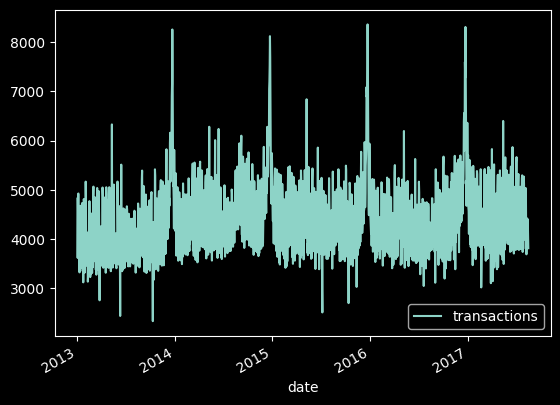

In [52]:
# Setting the index to the date column makes it our X-axis automatically
# The semicolon suppresses the text output from matplotlib
transactions_44.set_index('date').plot();

#### Plotting Multiple Series

What if we want to compare Store 44 and Store 47 on the same chart? 

As mentioned earlier, **Pivot Tables** are a fantastic way to get your data in shape for plotting. By pivoting, we can force our dates into the index, and turn our store numbers into separate columns (which pandas will plot as separate lines!).

In [53]:
# Step 1: Filter to our two stores of interest
two_stores = transactions.query("store_nbr in [44, 47]")

# Step 2: Pivot the table (Dates as index, Stores as columns, Transactions as values)
stores_pivoted = two_stores.pivot_table(
    index='date', 
    columns='store_nbr', 
    values='transactions'
)

stores_pivoted.head()

store_nbr,44,47
date,,
2013-01-02,4821.0,4161.0
2013-01-03,3618.0,3660.0
2013-01-04,4169.0,3915.0
2013-01-05,4921.0,4764.0
2013-01-06,4925.0,4935.0


Now that we have one row per date and separate columns for our stores, calling `.plot()` will automatically generate a beautiful multi-line chart comparing the two.

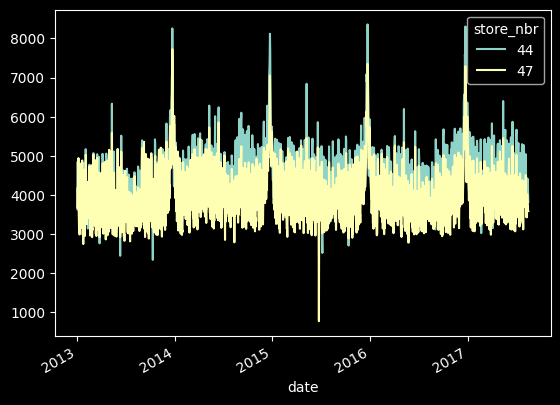

In [54]:
# Plotting the pivoted DataFrame
stores_pivoted.plot();

This is a great start! We can clearly see spikes in sales around the holidays, and we can tell that Store 47 generally has lower sales than Store 44.

Next, we will learn how to format these charts to make them look more professional and easier to read!

### 2.2 Chart formatting and titles

We just saw an example of using the `plot()` method to create a line chart, but everything we plotted was using the chart formatting defaults. There are a ton of options for formatting plots in Python! 

We're going to walk through a handful of the most critical ones:
* Titles and Axis Labels
* Colors
* Legends
* Figure Size
* Grids and Subplots

Let's start with arguably the most important formatting: the **chart title** and **axis labels**. 



By default, pandas uses the DataFrame's column names as the labels. Sometimes those defaults aren't great for a presentation. We can add custom chart titles and axis labels to increase understanding using the `title`, `xlabel`, and `ylabel` arguments.

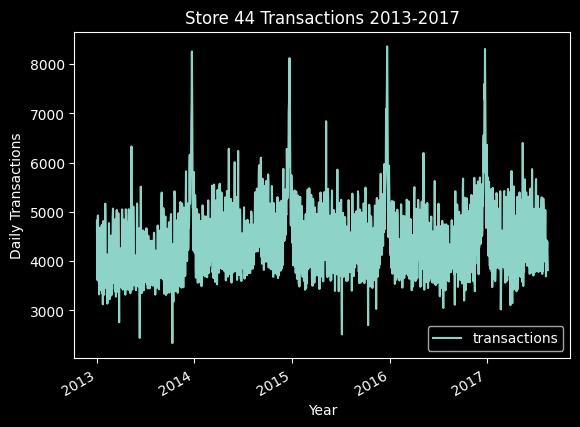

In [55]:
# Recreating our Store 44 plot, but adding formatting arguments
# Note: Breaking these arguments into multiple lines makes the code much easier to read!

transactions_44.set_index('date').plot(
    title='Store 44 Transactions 2013-2017',
    xlabel='Year',
    ylabel='Daily Transactions'
);

**Instructor Tip:** 

When I'm just exploring data for myself, I often don't add a title because I know what the data represents. However, if you are going to share this with others, labels are absolutely critical.

That being said, sometimes I intentionally leave the title *off* if I'm planning to put the image into a presentation tool like PowerPoint! Sometimes fine-tuning fonts, sizes, and colors for a single slide is a lot more work in Python than just pasting the raw chart image into PowerPoint and using their built-in text boxes to match the company style guide.

Next, let's take a look at how to customize **colors**!

### 2.3 Chart colors

Now let's take a look at changing the colors in our charts. We can modify the colors of our data series by specifying common color names or by using Hex codes.

Matplotlib will understand basic colors like `'black'`, `'red'`, `'green'`, `'blue'`, etc. There are also single-letter shorthands, like `'k'` for black. We pass these into the `color` (or `c`) argument of the `.plot()` method.

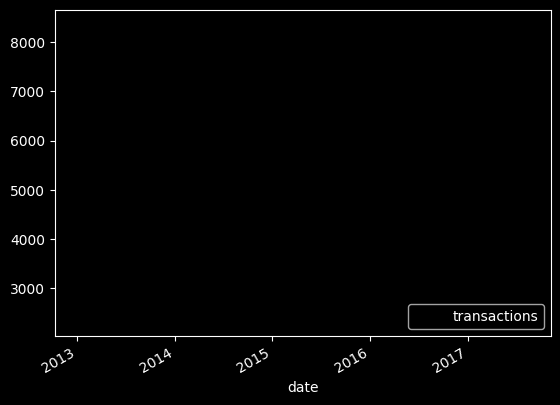

In [56]:
# Plotting a single series with a basic color name (or shorthand)
transactions_44.set_index('date').plot(color='k');

#### Hexadecimal Codes

We are not limited to common color names. We can feed in *any* color to our charts by using Hexadecimal codes. If your company has a specific style guide, it almost certainly contains the Hex codes you need to get your corporate colors into your chart.



You don't need to memorize these! You can use tools like Google's Hex Color Picker to find the exact shade you want (e.g., a nice teal).

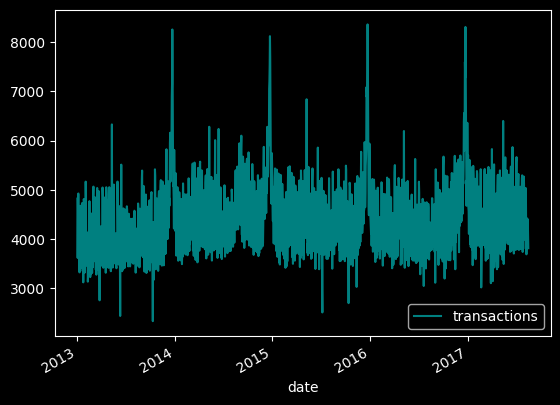

In [57]:
# Using a specific Hex code for our line color
transactions_44.set_index('date').plot(color='#008080');

#### Multiple Series and Colormaps

If we have multiple series in our chart, we can pass a **list** of colors. The colors will be assigned in the order that the columns appear in our DataFrame.

Alternatively, we can use **Colormaps** (`cmap`). Colormaps are predefined sequences of colors that our charts draw on as we add more series. By default, pandas cycles through blue, orange, green, red, etc.



Depending on the type of chart you're building, you might want *Sequential* colors (great for scatter plots or heatmaps) or *Qualitative* colors (great for distinct lines, like `'tab10'` or `'Pastel2'`).

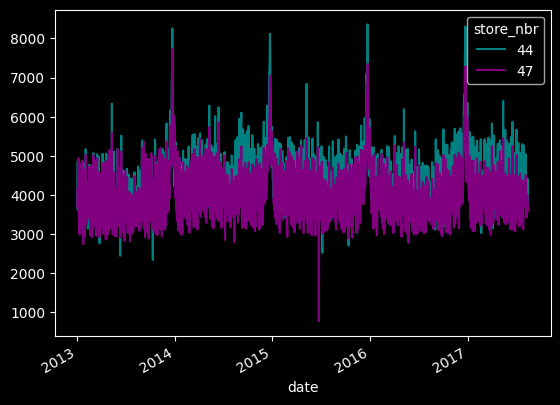

In [58]:
# Providing a list of specific Hex colors for multiple series
stores_pivoted.plot(color=['#008080', '#800080']);

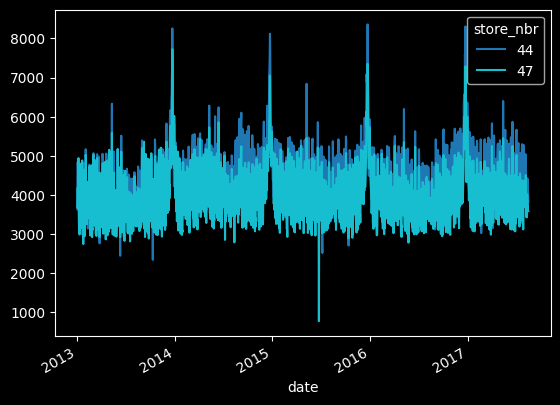

In [59]:
# Using a built-in Matplotlib colormap (cmap) instead of manual colors
stores_pivoted.plot(cmap='tab10');

#### Transparency (`alpha`)

Finally, one last helpful trick is the `alpha` argument. This controls the transparency of your plotted elements.

* `alpha=1.0`: Completely solid (default)
* `alpha=0.0`: Completely invisible
* `alpha=0.5`: 50% transparent

This is incredibly useful when you have multiple series overlapping each other, allowing you to see data lurking behind other data!

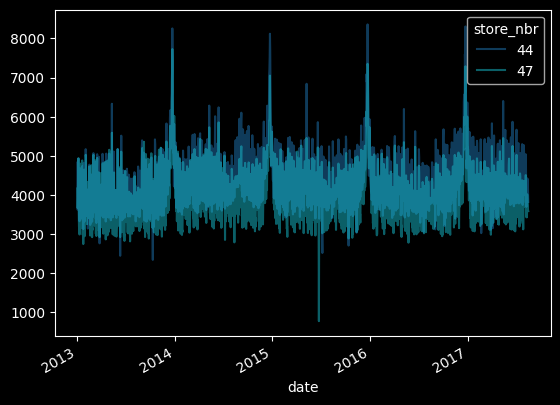

In [60]:
# Adding transparency to our lines to see overlapping patterns better
stores_pivoted.plot(cmap='tab10', alpha=0.5);

### 2.4 Line styles

The lines in our line charts are solid by default, but we can change the line style if needed. This provides an extra layer of visual distinction between two lines, which is particularly useful if we need to save our chart in a format that requires us to keep our line colors the same (like black and white printing).

Some of the most commonly used line styles are:
* `solid` (default)
* `dashed`
* `dashdot`
* `dotted`



To change the line styles, all we need to do is pass a list of style arguments into the `style` parameter of the `.plot()` method.

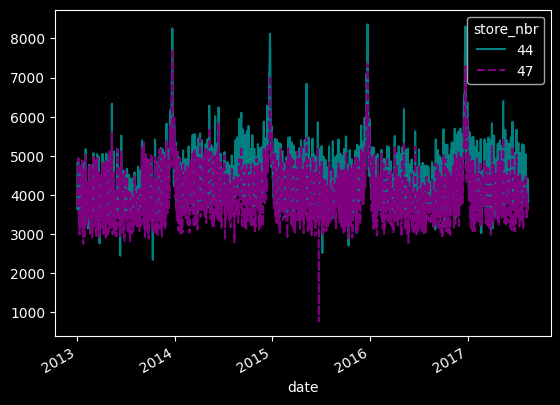

In [61]:
# Applying different line styles to our two series
# FIX: pandas/matplotlib expect line format strings here, not full words.
stores_pivoted.plot(
    color=['#008080', '#800080'], 
    style=['-', '--']
);

**A quick note on data density:**

If you run the code above, it might actually be hard to see the dashing! That is because we are plotting so much data (years of daily transactions) that the dashes get squished together.

If we want to make the line styles more clear, we should filter our data down to a smaller time frame, like a single year. Since our index is a datetime object, we can easily filter it.

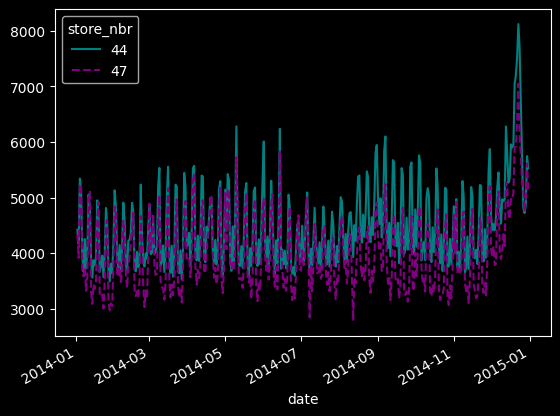

In [62]:
# Filtering to just the year 2014 so the dashed line emerges more clearly
stores_pivoted[stores_pivoted.index.year == 2014].plot(
    color=['#008080', '#800080'], 
    style=['-', '--']
);

While there are a few more line style options deep in the Matplotlib documentation, these core styles will cover the vast majority of your visualization needs.

Next, let's look at customizing chart legends and grid lines!

### 2.5 Chart legends and gridlines

Our legend is often very important in a chart because it communicates to users what our lines represent. However, legends can be finicky! By default, pandas (via Matplotlib) tries to place your legend in the "best" spot—looking for regions of whitespace where it won't obscure your data.

Sometimes, there simply isn't a good spot inside the chart, or perhaps you want to create a custom legend in PowerPoint later. In these cases, you might want to turn the legend off entirely using `legend=False`.

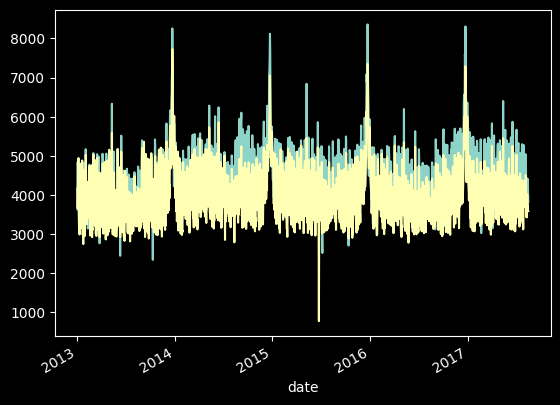

In [63]:
# Turning off the legend completely
stores_pivoted.plot(legend=False);

#### Repositioning the Legend

More likely than not, you'll want to keep the legend but move it to a better location. We can do this by chaining the `.legend()` method to our plot and specifying a `loc` argument (e.g., `'upper center'`, `'center left'`).



*(Note: Because `.plot()` returns a Matplotlib axes object, we can chain methods directly onto it!)*

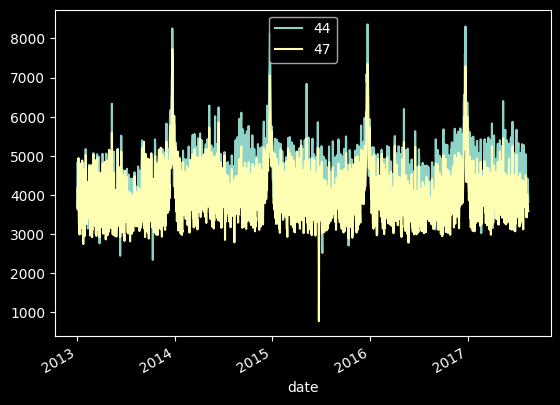

In [64]:
# Moving the legend to the upper center
stores_pivoted.plot().legend(loc='upper center');

If you need precise control—for example, to move the legend completely *outside* the chart area—you can use the **`bbox_to_anchor`** argument. This accepts a tuple of coordinates `(x, y)` relative to the chart area.

* `(0, 0)` is the bottom left.
* `(1, 1)` is the top right.

By setting values slightly larger than 1, we can push the legend outside the frame.

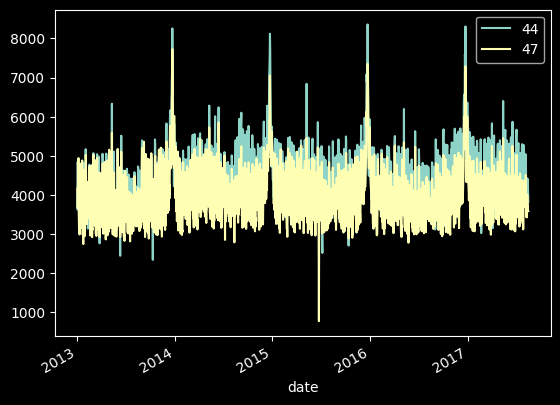

In [65]:
# Using bbox_to_anchor to push the legend outside the chart (top right)
stores_pivoted.plot().legend(bbox_to_anchor=(1, 1));

#### Gridlines

Finally, adding gridlines can make charts easier to read. While customizing them (e.g., vertical only) requires diving deeper into Matplotlib, you can turn on standard gridlines simply by passing `grid=True` to the plot method.

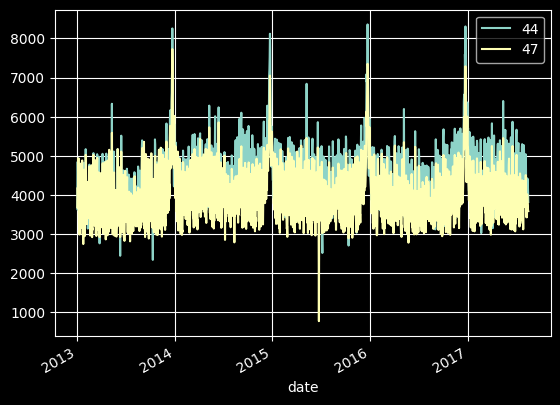

In [66]:
# Adding gridlines to the chart
stores_pivoted.plot(grid=True).legend(bbox_to_anchor=(1, 1));

### 2.6 Chart styles

Customizing our charts manually in pandas and Python is quite a bit of work. If you want to customize your charts to a very high level from scratch, you eventually need to learn the Matplotlib and Seaborn libraries deeply (which could be an entire course in itself!).

However, one thing that can help us get around the need to learn these libraries very deeply right now is using **pre-made style templates** provided to us by Matplotlib and Seaborn.



Once we set a style at the top of our notebook, it will be applied to all charts we make below it. Let's start by importing Seaborn and setting the style to `'darkgrid'`, which gives us a nicer background color and better font sizing than the basic defaults.

In [67]:
import seaborn as sns

# Setting a pre-built Seaborn style
sns.set_style("darkgrid")

# Let's plot our data without any custom formatting to see the new default
stores_pivoted.plot();

ModuleNotFoundError: No module named 'seaborn'

You get really nice pre-built defaults this way as opposed to coding all of those background grids and font sizes by hand! 

We can do the same thing with Matplotlib's built-in styles. A very popular one is `'fivethirtyeight'` (mimicking the style of the data journalism website FiveThirtyEight).



**Important:** We can still customize *on top* of these style sheets! Any arguments we specify in our `.plot()` method (like `color`, `linestyle`, or `alpha`) will overwrite what was in the template.

In [ ]:
import matplotlib.pyplot as plt

# Setting a pre-built Matplotlib style
plt.style.use('fivethirtyeight')

# The fivethirtyeight style uses very thick lines by default.
# Let's override the template slightly by adding some transparency (alpha).
stores_pivoted.plot(alpha=0.7);

There are dozens of styles out there. If you want to just pick one of these styles and stick with it, it will save you a massive amount of formatting work in the future without needing to become a Matplotlib expert.

Now that we've taken a look at chart styling and formatting, let's get some practice with these concepts in an assignment!

### 2.7 Subplots and figure size

By default, when we plot a DataFrame with multiple numeric series, they are all plotted within the same chart area. A lot of the time that's exactly what we want. But if we ever want to break these out into separate plots to give the data room to breathe, we can use **subplots**.

Calling the plot method with `subplots=True` creates a separate chart for each series of our data. By default, it will stack them all vertically into a single column.

In [ ]:
# Plotting multiple series as separate subplots
stores_pivoted.plot(subplots=True);

#### Layouts and Shared Axes

We can modify this vertical stacking behavior by specifying a `layout` argument (e.g., passing a tuple like `(2, 2)` for a 2x2 grid, or `(1, 2)` for side-by-side).



**Crucial Tip:** When comparing similar series next to each other, you should almost always specify `sharey=True`.



One of the easiest ways to deceive ourselves (and our audience) is to allow a separate Y-axis scale for each chart. If the peaks look the same height, but one axis maxes out at 8,000 and the other at 4,000, the viewer will draw the wrong conclusion. Sharing the Y-axis forces them onto the exact same scale.

In [ ]:
# Creating a side-by-side layout and forcing a shared Y-axis for honest comparison
stores_pivoted.plot(
    subplots=True, 
    layout=(1, 2), 
    sharey=True
);

#### Figure Size (`figsize`)

When we start creating more complex charts like grids of subplots, they can easily get bunched up and hard to read. We can increase the physical dimensions of the generated image using the **`figsize`** argument.

The default chart size is 6.4 by 4.8 inches. We pass a tuple of `(width, height)` to change this. Let's make it 10x10 and give our side-by-side charts plenty of room!

In [ ]:
# Increasing the figure size to 10x10 inches
stores_pivoted.plot(
    subplots=True, 
    layout=(1, 2), 
    sharey=True, 
    figsize=(10, 10)
);

Increasing the `figsize` also produces higher-resolution images, which look much cleaner if you plan to copy/paste them or save them for a presentation.

That covers subplots and figure sizing! Let's go ahead and get some practice with these in an assignment.

### 2.8 Bar charts

We've taken a pretty in-depth look at the line chart, which is the default chart when we call the `plot()` method. But there are quite a few other chart types available to us in Matplotlib!

In order to change our chart type, we have two main options:
1. **The `kind` argument:** `df.plot(kind='bar')`
2. **Chained chart methods:** `df.plot.bar()`

**Instructor Preference:** I highly prefer the second method (`.plot.bar()`). When we explicitly chain the chart type, the specific arguments for *that* chart live inside its own attribute. If we just use `kind='bar'`, there's a higher chance we could accidentally use invalid arguments, and our code can get messy.

#### Line vs. Bar Charts

* **Line Charts:** Useful for showing trends and changes over time. The X-axis should be continuous (like a date).
* **Bar Charts:** Useful for making comparisons with categorical data. It doesn't make sense to draw a line between "Groceries" and "Vegetables"!
* **Pie Charts:** Useful for showing parts of a whole or proportions. They work best when you have a small number of categories and want to highlight how each slice contributes to the 100% total (like breaking down your monthly expenses).
* **Histograms:** Useful for showing the distribution of continuous numerical data. While they look a lot like bar charts, the bars touch each other because they represent continuous ranges or "bins" (like tracking how many people fall into the 20-29, 30-39, and 40-49 age groups) rather than completely separate categories.
* **Scatter Plots:** Useful for revealing the relationship or correlation between two different numerical variables. Each point represents a single observation, making it easy to spot trends, clusters, or outliers (like plotting "hours studied" on the X-axis and "test scores" on the Y-axis to see if there's a connection).

<img src="chart_types.png" width="400">

Let's aggregate our total transactions by `store_nbr` and create a vertical bar chart.

In [ ]:
# Grouping by store number to get total transactions
store_transactions = transactions.groupby('store_nbr').agg({'transactions': 'sum'})

# Creating a vertical bar chart and expanding the figure size so the X-axis can breathe
store_transactions.plot.bar(figsize=(12, 6));

We can clearly see that the stores in the 40s are having much higher sales than most of the others. Let's filter our DataFrame down to just those stores to make the chart easier to read.

We will also switch to a **Horizontal Bar Chart (`barh`)**. 

**Important Quirk:** If we want our largest value to be at the *top* of a horizontal bar plot, we actually need to sort our data in *ascending* order before plotting! (A similar quirk exists in Excel).

In [ ]:
# Defining our list of stores in the 40s
store_40s = list(range(40, 50))

# Chaining our operations: group -> aggregate -> query -> sort -> plot.barh
(transactions
 .groupby('store_nbr')
 .agg({'transactions': 'sum'})
 .query("store_nbr in @store_40s")
 .sort_values(by='transactions', ascending=True)
 .plot.barh(figsize=(10, 6), title='Total Transactions: Stores 40-49')
);

Now we have a beautiful horizontal bar chart where it is extremely easy to see that Store 44 outpaces the rest, while Store 42 really lags behind.

Now that we've taken a look at simple bar charts, let's up the ante a little bit by looking at grouped and stacked bar charts!

### 2.9 Grouped and stacked bar charts

We just saw an example of creating a bar chart out of a single series. If we plot a DataFrame with *multiple* numerical columns using a bar chart, pandas will automatically create a **grouped bar chart**.

Let's do a little bit of data preparation first. We are going to query our transactions table for stores in the 40s, filter down to the first three months of the year, and create a pivot table where the `index` is our month and the `columns` are our store numbers.

In [ ]:
# Data preparation: filtering and pivoting
stores_40s_q1 = transactions.query("store_nbr in @store_40s and date.dt.month <= 3")

pivot_q1 = stores_40s_q1.pivot_table(
    index=stores_40s_q1['date'].dt.month, 
    columns='store_nbr', 
    values='transactions', 
    aggfunc='sum'
)

pivot_q1.head()

Now, if we just call `.plot.bar()` on this DataFrame, we will get a grouped bar plot. The rows (months) become our X-axis, and we get a separate bar for each store within that month.

In [ ]:
# Creating a grouped bar chart (default behavior for multiple columns)
pivot_q1.plot.bar(figsize=(10, 6));

#### Stacked Bar Charts

In addition to grouped bar charts, we can easily create **stacked bar charts**. All we need to do is specify `stacked=True` inside our plot method. 

This allows us to compare the total sales for each month, while *also* showing the composition of which stores contributed to that total.

In [ ]:
# Creating a stacked bar chart
pivot_q1.plot.bar(stacked=True, figsize=(10, 6));

*(Note: You can easily do the exact same thing with horizontal bar charts by using `.plot.barh(stacked=True)` instead!)*

#### 100% Stacked Bar Charts

Finally, we can also create **100% stacked bar charts**. This view emphasizes composition rather than total volume. We care less about the absolute total sales, and more about the *percentage* each store contributed to the month.



To do this, we need to do a little bit of data manipulation before plotting. We will use the `.apply()` method with a `lambda` function across our rows (`axis=1`). For each cell, we will multiply it by 100 and divide by the sum of its row.

In [ ]:
# Transforming the data to represent percentages of the row total
pivot_q1_pct = pivot_q1.apply(lambda x: x * 100 / sum(x), axis=1)

pivot_q1_pct.head()

Now that all the values in a single row add up to 100, plotting a standard stacked bar chart will result in a 100% stacked bar chart!

In [ ]:
# Plotting the 100% stacked bar chart
pivot_q1_pct.plot.bar(stacked=True, figsize=(10, 6)).legend(bbox_to_anchor=(1, 1));

Those are grouped and stacked bar charts in a nutshell! Now it's time to get some practice with these in an assignment.

### 2.10 Pie charts and scatterplots

Let's take a look at a controversial chart type: the **Pie Chart**. In some circles, pie charts are looked down upon, but they can be useful for showing composition with categorical data as a percentage of 100.

**Best Practices for Pie Charts:**
* **Limit Categories:** Pie charts get very hard to read with more than 5 categories.
* **Sort Slices:** Sort your data from highest to lowest.
* **Start Angle:** Use `startangle=90` to start the first slice at the top (12 o'clock position).



In [ ]:
# Preparing data for a pie chart: aggregating total transactions by store
# We'll filter to just a few stores to keep the pie chart readable
pie_data = transactions.query("store_nbr in [44, 45, 46, 47]").groupby('store_nbr').agg({'transactions': 'sum'})

# Plotting the pie chart
# Note: We must specify y='transactions' so pandas knows which column to plot
pie_data.plot.pie(
    y='transactions', 
    figsize=(7, 7), 
    startangle=90, 
    autopct='%1.1f%%'
).legend(bbox_to_anchor=(1, 1));

#### Scatterplots

Scatterplots are useful for showing the **relationship** (correlation) between two numerical series. 

* **Positive Correlation:** Dots move from bottom-left to top-right.
* **Negative Correlation:** Dots move from top-left to bottom-right.
* **No Correlation:** A random cloud of dots.

[Image of scatter plot correlation types positive negative no correlation]

To plot a scatterplot, we usually need our data in a wide format (where the two series we want to compare are in separate columns). Let's pivot our data so we have months as rows and stores as columns.

In [ ]:
# Pivoting data to compare Store 44 vs Store 47 performance by month
pivot_monthly = transactions.pivot_table(
    index=transactions['date'].dt.month, 
    columns='store_nbr', 
    values='transactions', 
    aggfunc='sum'
)

pivot_monthly.head()

Now we can call `.plot.scatter()` and explicitly specify our `x` and `y` arguments.

In [ ]:
# Plotting a scatterplot to see if Store 44 and Store 47 sales are correlated
pivot_monthly.plot.scatter(
    x=44, 
    y=47, 
    title='Monthly Sales Correlation: Store 44 vs 47', 
    figsize=(8, 6)
);

We can see a pretty strong linear relationship here! As sales at Store 44 increase, sales at Store 47 also tend to increase.

Let's go ahead and get a little bit more practice with these in an assignment.

### 2.11 Histograms

Let's take a look at the last chart we're going to cover in this course: the **Histogram**. 

Histograms are incredibly useful for showing the distribution of a numerical series. They divide the data into "bins" and plot the frequency of values that fall into each bin as bars.



This really helps us get a fuller picture of the shape of our data, giving visual context to the high-level statistics (like mean, min, and max) we get from the `.describe()` method. It also makes it very easy to spot potential outliers!

In [ ]:
# Plotting a basic histogram of all transactions
transactions['transactions'].plot.hist(figsize=(8, 5), title='Distribution of All Transactions');

Looking at that, we can see the distribution for all of our stores is centered around just under 2,000 transactions per day.

Generally speaking, building a histogram is one of those times we are *not* aggregating our data first. We want to see the raw row-level distribution. We might, however, want to filter our data down to a single entity, like a specific store.

In [ ]:
# Filtering to just Store 47 and plotting its specific distribution
transactions.query("store_nbr == 47")['transactions'].plot.hist(
    figsize=(8, 5), 
    title='Distribution of Transactions: Store 47'
);

Because Store 47 is one of our biggest-selling stores, its distribution is shifted much higher (between 3,000 and 6,000) with a small tail stretching out to 8,000.

#### Overlapping Histograms and Transparency (`alpha`)

We can also plot multiple distributions against each other. If we try to plot two histograms on top of each other, it will be really hard to see the shape of the one in the back because it will be obscured by the solid color of the one in the front.



To fix this, we use the **`alpha`** argument to set transparency (0 = invisible, 1 = solid). Let's plot Store 44 and Store 47 together using the pivoted DataFrame we created earlier to compare their distributions.

In [ ]:
# Using our pivoted DataFrame to plot multiple overlapping histograms
# Setting alpha=0.5 makes them semi-transparent so we can see both shapes
stores_pivoted.plot.hist(
    alpha=0.5, 
    figsize=(10, 6), 
    title='Transaction Distributions: Store 44 vs Store 47'
);

By adding `alpha=0.5`, we can clearly see where the two distributions overlap and where they differ!

Let's go ahead and get some more practice with this in an assignment where you'll get a chance to plot multiple series.

### 2.12 Saving plots and further exploration

You've just built the most beautiful chart that's ever been created... how do we save this thing as an image to share it with other people?

When we call `.plot()`, pandas actually returns a Matplotlib `Axes` object. We can assign this to a variable (like `ax`), and then access the underlying figure to save it using the **`savefig()`** method.

**Important Argument:** When saving, it is highly recommended to pass `bbox_inches='tight'`. This ensures that any elements sitting outside the main plot area (like a custom-positioned legend) don't get accidentally cropped out of your saved image file!

In [ ]:
# Creating our plot and assigning the returned Axes object to the variable 'ax'
ax = pivot_monthly.plot.scatter(
    x=44, 
    y=47, 
    title='Monthly Sales Correlation: Store 44 vs 47', 
    figsize=(8, 6)
)

# Accessing the figure from the axes and saving it as a high-quality PNG file
ax.figure.savefig('store_correlation_scatter.png', bbox_inches='tight')

While you can always use the Snipping Tool (Windows) or `Cmd+Shift+4` (Mac) to take a quick screenshot of your notebook, using `savefig()` guarantees a high-quality, high-resolution image file that is perfectly reproducible every time you run your code.

---

#### Further Exploration: The Python Data Visualization Ecosystem

Because pandas is so popular, almost all data visualization libraries in Python are built to seamlessly work with pandas Series and DataFrames. 

The pandas `.plot()` API is fantastic for quick exploration and basic formatting. However, to get more chart types, advanced interactivity, or geospatial plotting, you will want to explore these dedicated libraries:

* **Matplotlib:** The foundational library. You can create almost *any* type of image if you put enough work into it, but it can be very challenging and verbose to learn deeply.
* **Seaborn:** Built on top of Matplotlib, but much easier to work with. It features beautiful default visuals, statistical plotting out-of-the-box, and new chart types. *This is highly recommended as your next visualization library to learn!*
* **Plotly (and Dash):** Excels at interactive charts and dashboards. If you want users to be able to hover, zoom, and click on your charts, or if you want to build web applications, Plotly is the go-to tool.
* **Folium:** A specialized library built specifically for geospatial mapping and interactive map-based visuals.




The goal of this section was to give you just enough visualization tools to credibly explore your data and format basic charts for your colleagues. To build world-class visuals, definitely dive into the libraries above!